In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys
sys.path.append('/content/drive/MyDrive/cocktail_dmlr/feature_interaction')

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.svm import SVR
import functions_case as il
import importlib
importlib.reload(il) # reloads package after changes have been made
from sklearn.base import clone
from sklearn.model_selection import train_test_split
import itertools
from sklearn.ensemble import RandomForestClassifier
from functools import partial
import multiprocessing as mp
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

In [4]:
dataset_path = "/content/drive/MyDrive/cocktail_dmlr/Data_cleaned/menu_6_cleaned.csv"
dataset_name  = "menu_cleaned"
results_dir   = "/content/drive/MyDrive/cocktail_dmlr/results_dg_binary"

In [5]:
# Load & prepare data
df      = pd.read_csv(dataset_path)
meta_cols = ["name", "dg_rating", "dd_rating"]

# 1. Extract ingredient columns
ingredient_cols = [col for col in df.columns if col not in meta_cols]

# 2. Compute top 200 most frequent ingredients
top200 = df[ingredient_cols].sum().sort_values(ascending=False).head(200).index.tolist()

# 3. Define X and y
X       = df[top200]
y_cont  = df["dg_rating"]
y_str   = np.where(y_cont <= 4.0, "fair", "good")        # binary label
le      = LabelEncoder()
y       = le.fit_transform(y_str)

In [6]:
def get_mp_metric(X, Y, n_ratio, m_ratio, B, model, feature_pairs):
    """
    Computes interaction metrics (iLOCO) for multiple feature pairs using an ensemble model.

    Parameters:
    X (numpy.ndarray): Feature matrix.
    Y (numpy.ndarray): Target variable.
    n_ratio (float): Ratio parameter for ensemble fitting.
    m_ratio (float): Ratio parameter for ensemble fitting.
    B (int): Number of bootstrap samples.
    model (object): Trained model for interaction computation.
    feature_pairs (list of tuples): List of tuples where each tuple contains two feature indices (j1, j2) for the feature pair.

    Returns:
    dict: Dictionary where keys are feature pairs (j1, j2) and values are dictionaries containing:
          - 'iloco': The mean interaction value.
          - 'iloco_max': The maximum interaction value, ensuring non-negative.
          - 'iloco_ratio': The ratio of iloco to the mean of r.
    """
    # Create and fit an ensemble model
    ensemble = il.Ensemble(model).fit(X, Y, n_ratio, m_ratio, B)

    # Compute feature interactions for the given list of feature pairs
    result = il.featureInteractions(X, Y, n_ratio, m_ratio, B, model, feature_pairs)

    return result


In [7]:
#Set Parameters
J1 = 0
J2 = 1
m_ratio = 0.5
n_ratio = 0.5
B = 5000
m1 = LogisticRegression(solver="lbfgs", penalty="l2", max_iter=1000)

In [8]:
# Prepare features (X) and target (y)
feature_names = X.columns.tolist()
feature_pairs = list(itertools.combinations(range(X.shape[1]), 2))
X = X.to_numpy()


In [9]:
mp_results = []
mp_ci = []
mp_results = get_mp_metric(X, y, n_ratio, m_ratio, B, m1, feature_pairs)
mp_scores = [mp_results[(j, k)]['iloco'] for (j, k) in feature_pairs]
mp_ci = [mp_results[(j, k)]["ci"] for (j, k) in feature_pairs]

# Generate all pairwise combinations
pairwise_names = list(itertools.combinations(feature_names, 2))
# Convert each tuple to a single string
pairwise_names_str = [' & '.join(pair) for pair in pairwise_names]
data = {'ingredients': pairwise_names_str, 'scores': mp_scores, 'ci': mp_ci }
df = pd.DataFrame(data)




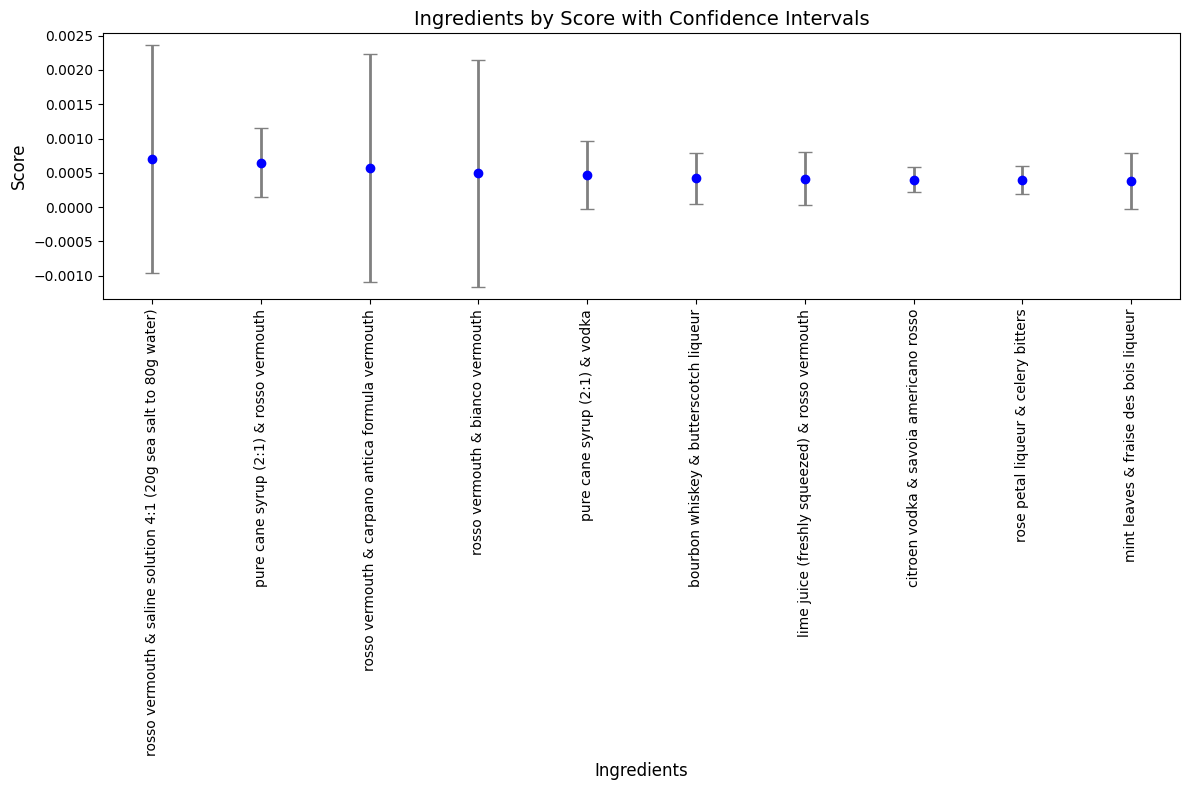

In [10]:
top_20 = df.nlargest(10, "scores")
# Plot
plt.figure(figsize=(12, 8))
plt.errorbar(
    top_20["ingredients"],
    top_20["scores"],
    yerr=top_20["ci"],
    fmt='o',  # Point marker
    color='blue',
    ecolor='gray',
    elinewidth=2,
    capsize=5
)
plt.xticks(rotation=90, fontsize=10)  # Rotate x-axis labels vertically
plt.ylabel("Score", fontsize=12)
plt.xlabel("Ingredients", fontsize=12)
plt.title("Ingredients by Score with Confidence Intervals", fontsize=14)
plt.tight_layout()  # Ensure everything fits nicely
plt.show()

In [11]:
df.to_csv("/content/drive/MyDrive/cocktail_dmlr/fi_dg_binary/iloco_xgb.csv", index=False)